# CCKS 2021 中文地址文本相关性 - 数据可视化与特征分析 (EDA)



## 需求对齐说明
- ✅ **完全实现的图表**：饼图、柱状图、百分比分布直方图、箱型图、小提琴图、KDEPlot、散点图、气泡图、词云图、热力图。
- ✅ **地理分布图**：通过正则提取地址文本中的“省份”，然后绘制条形图展示。
- ✅ **Network / 节点图**：利用 jieba 分词提取名词和地名，构建在同一地址中共现的“关联网络图”。
- ✅ **Subplots 组合图**：将六个基础单变量/双变量图表拼接到一个超大面板中。
- ❌ **暂不包含的图表**：误差棒图、折线+面积图、雷达图、混淆矩阵热力图。（强依赖机器学习模型输出结果的图表暂时空出）。


## 模块一：环境准备与全局配置

**原理说明**：
在数据可视化中，Python 最常用的两个核心库是 `matplotlib` 和 `seaborn`。
- `matplotlib` 是底层画图库，能画任何图，但默认样式比较简陋。
- `seaborn` 是基于 `matplotlib` 封装的高级库，提供好看的默认配色（主题），通常用极少的代码就能画出很精美的统计图表。

**中文乱码问题**：
`matplotlib` 默认不支持中文字体显示（如果不设置，中文会变成一个个小方块 `□□□`）。因此我们需要从你的 Windows 系统中加载字体（比如微软雅黑 `Microsoft YaHei`）并告诉 `matplotlib` 必须使用它。


In [13]:
import warnings
warnings.filterwarnings("ignore", message=".*Glyph.*missing from font.*")

# 导入所需的标准库
import json
import os
import re
from collections import Counter
from pathlib import Path

# 导入第三方分析与绘图库
import jieba                 # 用于中文分词
import jieba.posseg as pseg  # 词性标注（用于抽取地名名词画网络图）
import matplotlib.pyplot as plt # 核心绘图库
import numpy as np           # 数学计算库
import pandas as pd          # 数据处理核心库（主要使用 DataFrame 表格结构）
import seaborn as sns        # 高级统计绘图库
from matplotlib import font_manager as fm # 字体管理器
from wordcloud import WordCloud           # 词云图生成库
import networkx as nx        # 图论与复杂网络分析库，用来画 Network 节点图

# ================= 1. 路径配置 =================
# 定义当前 notebook 所在的目录，以及数据存放的相对位置
# 使用 pathlib.Path 处理路径比传统的 os.path.join 更优雅且跨平台
DATA_DIR = Path("../data")
OUTPUT_DIR = Path("../output_plots")
OUTPUT_DIR.mkdir(exist_ok=True) # 如果输出文件夹不存在则自动创建

# ================= 2. Seaborn 全局主题配置 =================
# 设置 seaborn 的画图主题为 'whitegrid'（白底 + 灰色网格线），这是数据分析最常用的清晰风格
# 注意：set_theme 必须在字体设置之前调用，否则会覆盖字体配置！
# sns.set_theme(style="whitegrid") # 移到下方执行

# 配置图片输出的分辨率 (DPI)。DPI 越高图片越清晰，300 属于印刷级别的超高清标准。
plt.rcParams["figure.dpi"] = 120    # Notebook 中显示的清晰度
plt.rcParams["savefig.dpi"] = 300   # 保存到本地图片文件的清晰度

# ================= 3. 解决中文字体显示问题 =================
def setup_matplotlib_font():
    """探测 Windows 系统中文字体并配置 matplotlib，返回字体文件路径供词云使用。"""
    candidate_fonts = [
        "C:/Windows/Fonts/msyh.ttc",     # 微软雅黑
        "C:/Windows/Fonts/simhei.ttf",   # 黑体
        "C:/Windows/Fonts/simsun.ttc",   # 宋体
    ]
    for font_path in candidate_fonts:
        if os.path.exists(font_path): # 如果在你电脑上找到了这个字体文件
            # 将字体加载到内存管理器中
            fm.fontManager.addfont(font_path)
            # 获取字体在系统中的官方名称（比如 'Microsoft YaHei'）
            font_name = fm.FontProperties(fname=font_path).get_name()
            # 告诉 matplotlib 全局使用这个字体
            plt.rcParams["font.family"] = font_name
            plt.rcParams["font.sans-serif"] = [font_name]
            # 解决坐标轴上的负号 '-' 显示为方块的问题
            plt.rcParams["axes.unicode_minus"] = False
            return font_path # 把路径返回，等会画词云图也要用
    return None

FONT_PATH = setup_matplotlib_font()
# 在成功探测并加载系统字体后，安全地配置 Seaborn 主题
sns.set_theme(style="whitegrid", font=plt.rcParams["font.sans-serif"][0] if plt.rcParams.get("font.sans-serif") else "sans-serif")

# ================= 4. 定义统一的配色方案 =================
# 为了让所有图表的颜色保持一致（而不是一张图红绿，另一张图紫黄）
# 我们用字典指定好三个类别的专属颜色
LABEL_COLORS = {
    "exact_match":   "#2ecc71",   # 翠绿色（代表完全正确/匹配）
    "partial_match": "#f39c12",   # 橙黄色（代表部分匹配）
    "not_match":     "#e74c3c",   # 红色（代表不匹配/错误）
}
# 定义标签的中文映射，方便在图表的图例中展示
LABEL_NAMES_CN = {
    "exact_match":   "完全匹配",
    "partial_match": "部分匹配",
    "not_match":     "不匹配",
}
# 定义固定顺序，使得每次画柱状图/饼图时，三个类别的位置都不会乱跑
LABEL_ORDER = ["exact_match", "partial_match", "not_match"]
PALETTE = [LABEL_COLORS[k] for k in LABEL_ORDER]


## 模块二：数据加载与特征工程

**原理说明**：
我们的原始数据（`dev.json`）只是单纯的两段中文地址和它们的相关度标签。
计算机是无法直接针对纯文本进行统计画图的，因此我们需要进行**特征工程（Feature Engineering）**：将非结构化的文本，转换为结构化的数值。

我们提取了以下特征用于画图：
1. **长度 (`len1`, `len2`)**：分别计算两段地址的字符个数。
2. **长度差与比值 (`len_diff`, `len_ratio`)**：评估两段话长度的差异幅度。
3. **文本重合度 (`overlap_ratio`, `jaccard`)**：用数学集合的概念，计算两个字符串有多少字是一样的。字一样得越多，相似度越高。
4. **编辑距离 (`edit_dist`)**：算法题常考的 Levenshtein 距离。它计算的是“把第一句话通过增删改字变成第二句话，最少需要几步操作”。操作步数越少，句子越像。
5. **省份提取 (`province`)**：由于数据里没有地理坐标（经纬度），我们写了一个包含全国省市名称的字典，通过遍历匹配的方法，从地址中强行提取出省份，从而实现你队友要求的“地理分布分析”。


In [14]:
def jaccard_similarity(s1: str, s2: str) -> float:
    """
    计算 Jaccard 相似度。
    原理：交集大小 除以 并集大小。
    例如 s1="北京朝阳", s2="北京海淀"，
    集合1={北,京,朝,阳}, 集合2={北,京,海,淀}
    交集={北,京} (2个)，并集={北,京,朝,阳,海,淀} (6个)，相似度 = 2/6 = 0.33
    """
    set1, set2 = set(s1), set(s2) # 转为集合（自动去重）
    if not set1 and not set2:
        return 1.0
    return len(set1 & set2) / len(set1 | set2)

def edit_distance(s1: str, s2: str) -> int:
    """
    使用动态规划计算编辑距离。
    """
    m, n = len(s1), len(s2)
    dp = list(range(n + 1))
    for i in range(1, m + 1):
        prev = dp[0]
        dp[0] = i
        for j in range(1, n + 1):
            temp = dp[j]
            if s1[i - 1] == s2[j - 1]:
                dp[j] = prev
            else:
                dp[j] = 1 + min(prev, dp[j], dp[j - 1])
            prev = temp
    return dp[n]

def overlap_ratio(s1: str, s2: str) -> float:
    """计算公共字符占较短句子长度的比例。"""
    set1, set2 = set(s1), set(s2)
    shorter = min(len(set1), len(set2))
    if shorter == 0: return 0.0
    return len(set1 & set2) / shorter

# ==== 基于硬编码的省份和城市词典，用于解决没有经纬度却要画地理分布的问题 ====
PROVINCES = ["北京", "天津", "上海", "重庆", "河北", "山西", "辽宁", "吉林", "黑龙江", 
             "江苏", "浙江", "安徽", "福建", "江西", "山东", "河南", "湖北", "湖南", 
             "广东", "海南", "四川", "贵州", "云南", "陕西", "甘肃", "青海", "台湾", 
             "内蒙古", "广西", "西藏", "宁夏", "新疆"]
CITY_TO_PROVINCE = {"杭州": "浙江", "宁波": "浙江", "南京": "江苏", "苏州": "江苏", 
                    "广州": "广东", "深圳": "广东", "成都": "四川", "武汉": "湖北",
                    "郑州": "河南", "济南": "山东", "沈阳": "辽宁", "哈尔滨": "黑龙江",
                    "西安": "陕西", "朝阳": "北京", "海淀": "北京", "浦东": "上海", 
                    "余杭": "浙江", "萧山": "浙江"}

def extract_province(text: str) -> str:
    """从地址文本中正则/暴力匹配提取省份。"""
    for prov in PROVINCES:
        if prov in text: return prov
    for city, prov in CITY_TO_PROVINCE.items():
        if city in text: return prov
    return "未知"

# ================= 加载并处理数据 =================
data_path = DATA_DIR / "dev.json"
records = []
print("正在读取 JSONL 文件并提取特征 (可能需要几十秒计算编辑距离)...")

with open(data_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line: continue
        item = json.loads(line)
        
        s1 = item.get("sentence1", "")
        s2 = item.get("sentence2", "")
        label = item.get("label", "")
        
        # 把每个句子的特征算好，存进一条字典记录里
        records.append({
            "sentence1": s1,
            "sentence2": s2,
            "label": label,
            "len1": len(s1),
            "len2": len(s2),
            "len_diff": abs(len(s1) - len(s2)),
            "jaccard": jaccard_similarity(s1, s2),
            "edit_dist": edit_distance(s1, s2),
            "province": extract_province(s1 + s2),
        })

# 把由字典组成的列表，转化为 pandas 的 DataFrame（超级表格），极大方便后续画图
df = pd.DataFrame(records)
print(f"✅ 特征构建完成！成功转换了 {len(df)} 条数据。")

# 预览前5行数据
df.head()


正在读取 JSONL 文件并提取特征 (可能需要几十秒计算编辑距离)...
✅ 特征构建完成！成功转换了 22974 条数据。


,sentence1,sentence2,label,len1,len2,len_diff,jaccard,edit_dist,province
0,凤城五路雅荷春天大门东侧、花语访花鲜花店,凤城五路雅荷春天(地铁2号线B口向东500米)花喜花艺(凤城五路店),partial_match,20,34,14,0.333333,22,未知
1,江苏省南京市秦淮区秦虹街道龙蟠南路33号4号地下车库负1层,龙蟠南路33号-9德佑(雅居乐花园店),partial_match,29,19,10,0.162162,25,江苏
2,:湖北省潜江市老新镇徐李村四组,潜江市老新镇,not_match,15,6,9,0.400000,9,湖北
3,宝应开发区中梁首府一号东阳三建项目部门卫室,兴越路中梁首府,not_match,21,7,14,0.166667,17,未知
4,江桥二村曲江路201弄14号,曲江路99弄江桥两村三街坊,not_match,14,13,1,0.352941,13,未知


## 模块三：超级组合面板 (Subplots)

**原理说明**：
使用 `Subplots` 组合图表。
`plt.subplots(nrows=2, ncols=3)` 能够一次性生成一个网格排版的“大画板”（Figure）和里面的 6 个“小画板”（Axes）。
我们可以在这 6 个小格子里面分别画上不同的图：饼图、柱状图、箱型图、小提琴图、直方图和散点图。
这样就可以在一张大图中鸟瞰所有单变量/双变量特征！


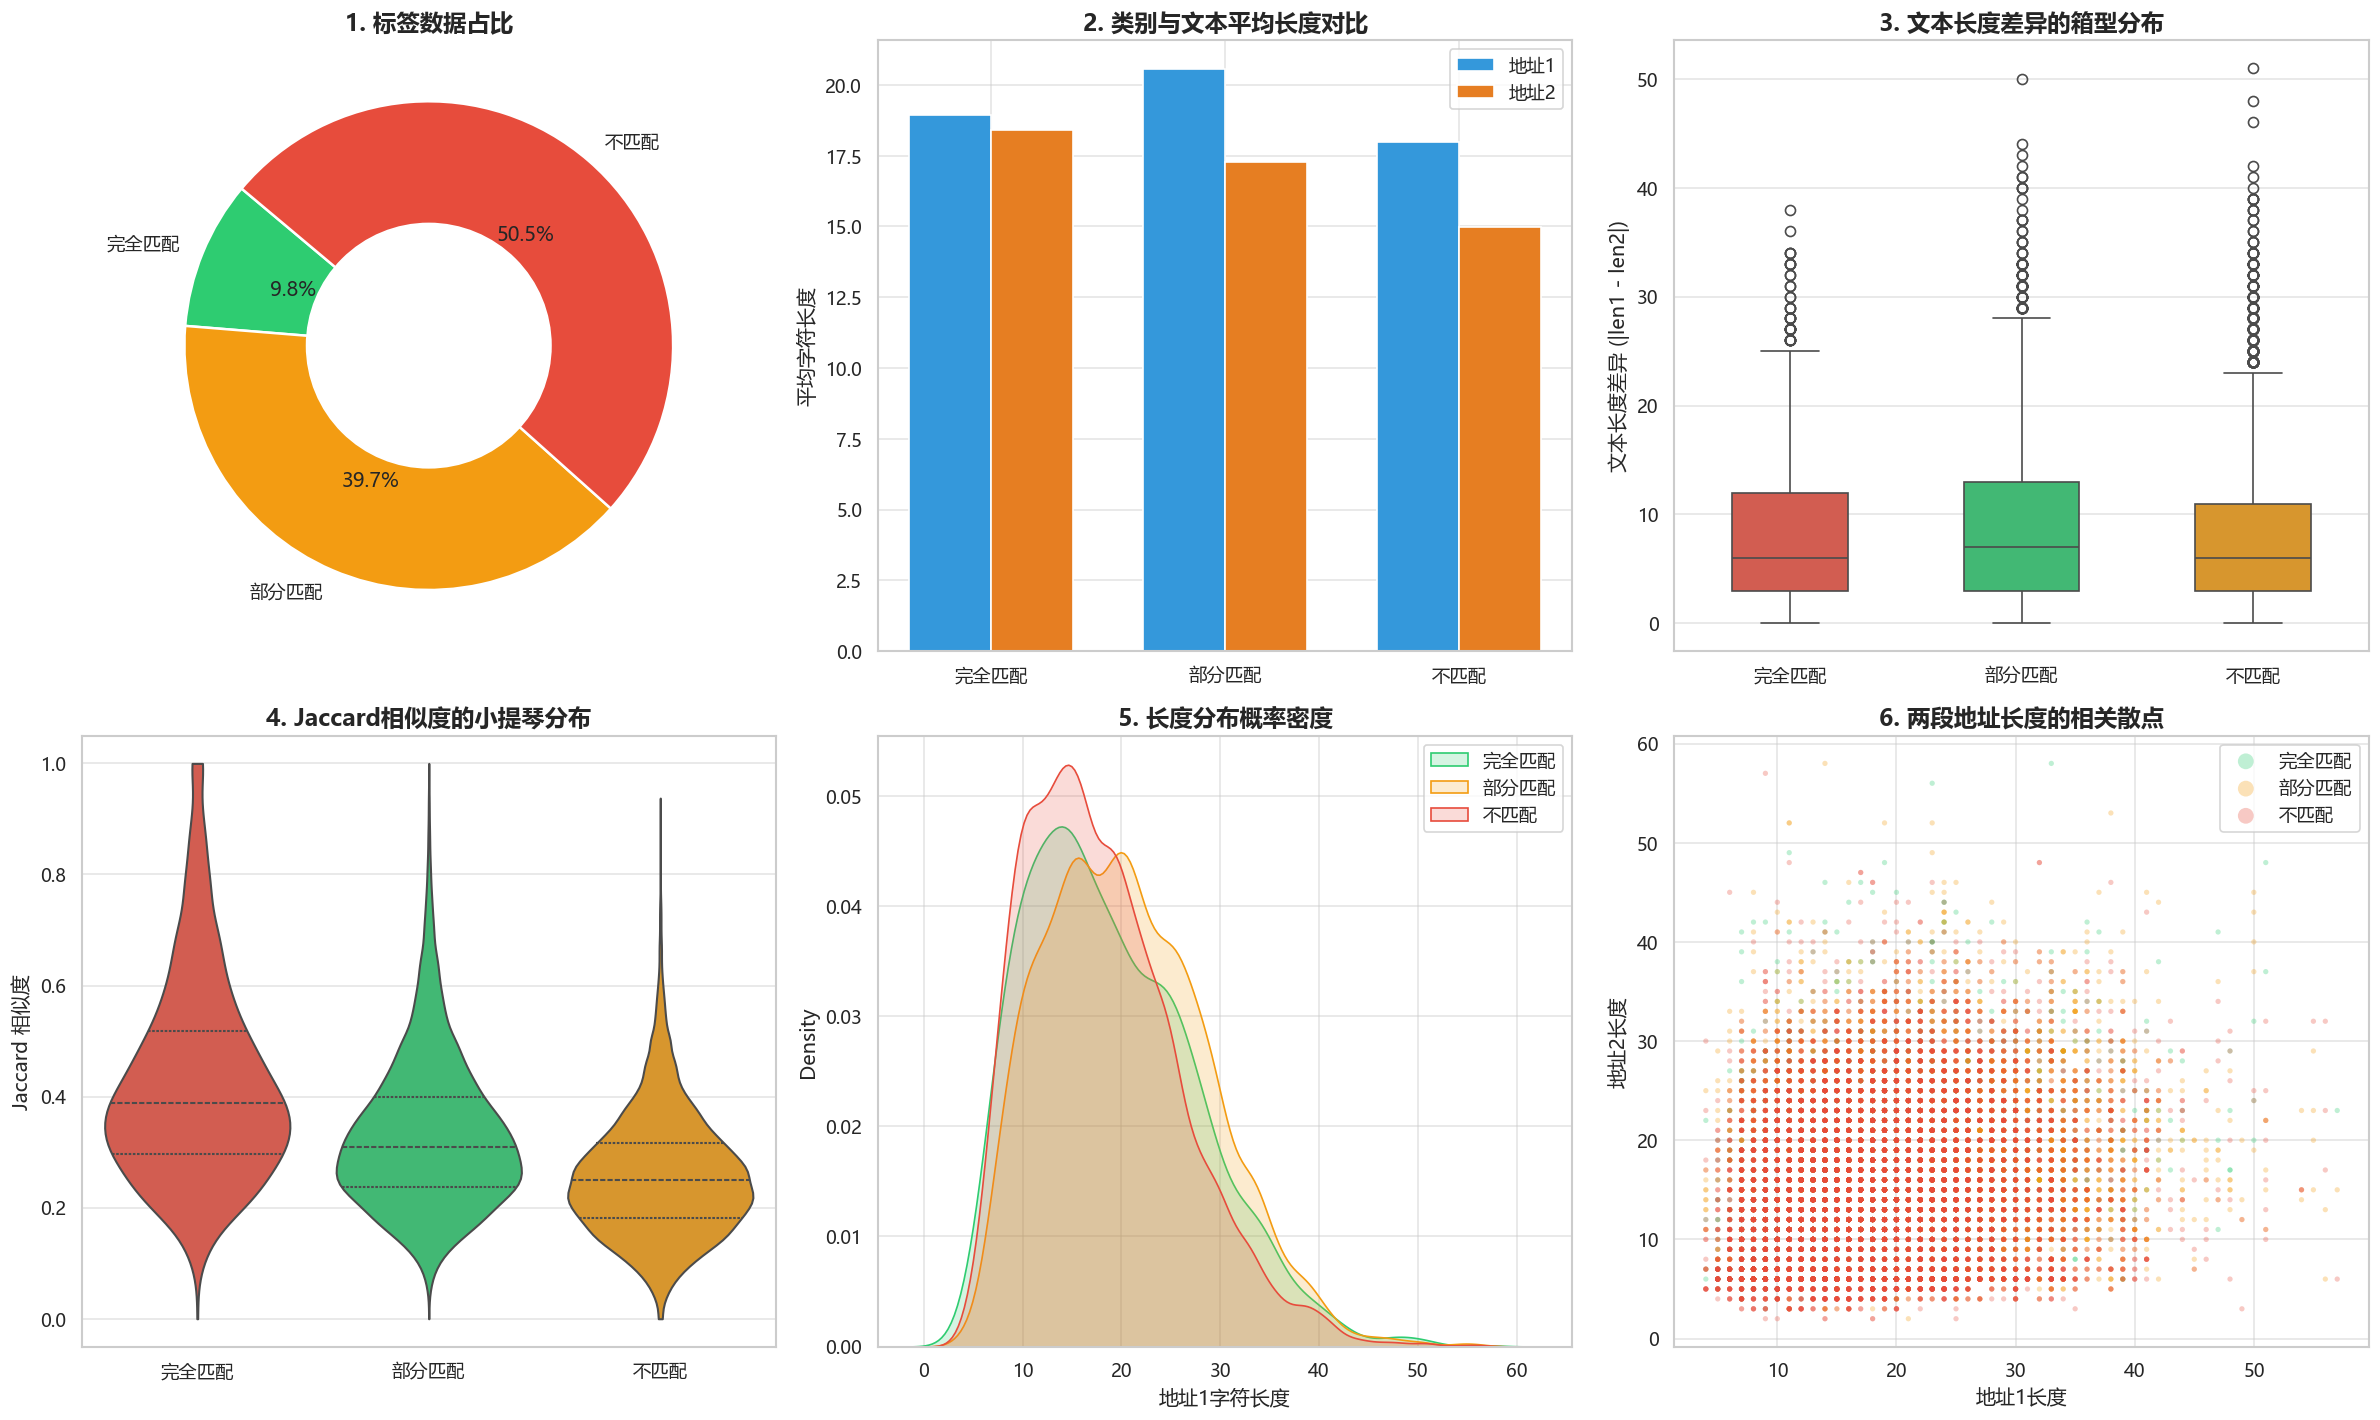

In [15]:
# 创建一个宽 20，高 12 的大画布，分为 2 行 3 列，共 6 个子图位置 (ax1 ~ ax6)
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
((ax1, ax2, ax3), (ax4, ax5, ax6)) = axes # 将坐标轴矩阵解包给独立的变量方便调用

df_plot = df.copy()
df_plot["label_cn"] = df_plot["label"].map(LABEL_NAMES_CN) # 把英文标签换成中文用于显示
order_cn = [LABEL_NAMES_CN[k] for k in LABEL_ORDER]

# ----------------- 子图 1：饼图 (标签分布) -----------------
counts = df["label"].value_counts().reindex(LABEL_ORDER)
ax1.pie(counts.values, labels=order_cn, colors=PALETTE, autopct="%1.1f%%", 
        startangle=140, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
# 绘制中心白圆，把它变成“环形图(Donut Chart)”，比纯饼图更现代
ax1.add_artist(plt.Circle((0, 0), 0.50, fc="white"))
ax1.set_title("1. 标签数据占比", fontsize=14, fontweight="bold")

# ----------------- 子图 2：柱状图 (平均长度) -----------------
# 用 pandas groupby 按类别求平均值
avg_data = df.groupby("label")[["len1", "len2"]].mean().reindex(LABEL_ORDER)
x = np.arange(len(LABEL_ORDER))
width = 0.35
ax2.bar(x - width/2, avg_data["len1"], width, label="地址1", color="#3498db")
ax2.bar(x + width/2, avg_data["len2"], width, label="地址2", color="#e67e22")
ax2.set_xticks(x)
ax2.set_xticklabels(order_cn)
ax2.set_ylabel("平均字符长度")
ax2.set_title("2. 类别与文本平均长度对比", fontsize=14, fontweight="bold")
ax2.legend()

# ----------------- 子图 3：箱型图 (长度差异分布) -----------------
# 箱型图展示的是数据的中位数、四分位数和异常值（离群点）
sns.boxplot(data=df_plot, x="label_cn", y="len_diff", order=order_cn, hue="label_cn", legend=False, 
            palette=PALETTE, width=0.5, ax=ax3)
ax3.set_xlabel("")
ax3.set_ylabel("文本长度差异 (|len1 - len2|)")
ax3.set_title("3. 文本长度差异的箱型分布", fontsize=14, fontweight="bold")

# ----------------- 子图 4：小提琴图 (Jaccard相似度) -----------------
# 小提琴图结合了箱型图和核密度图，能看出哪里数据最集中（肚子最胖的地方）
sns.violinplot(data=df_plot, x="label_cn", y="jaccard", order=order_cn, hue="label_cn", legend=False,
               palette=PALETTE, inner="quartile", cut=0, ax=ax4)
ax4.set_xlabel("")
ax4.set_ylabel("Jaccard 相似度")
ax4.set_title("4. Jaccard相似度的小提琴分布", fontsize=14, fontweight="bold")

# ----------------- 子图 5：核密度图 KDE (长度概率密度) -----------------
for label in LABEL_ORDER:
    subset = df[df["label"] == label]["len1"]
    sns.kdeplot(subset, ax=ax5, label=LABEL_NAMES_CN[label], 
                color=LABEL_COLORS[label], fill=True, alpha=0.2)
ax5.set_xlabel("地址1字符长度")
ax5.set_title("5. 长度分布概率密度", fontsize=14, fontweight="bold")
ax5.legend()

# ----------------- 子图 6：散点图 (len1 vs len2) -----------------
for label in LABEL_ORDER:
    subset = df[df["label"] == label]
    ax6.scatter(subset["len1"], subset["len2"], alpha=0.3, s=10, 
                color=LABEL_COLORS[label], label=LABEL_NAMES_CN[label], edgecolors="none")
ax6.set_xlabel("地址1长度")
ax6.set_ylabel("地址2长度")
ax6.set_title("6. 两段地址长度的相关散点", fontsize=14, fontweight="bold")
ax6.legend(markerscale=3)

# 统一调整间距并保存大图
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "EDA_Subplots_Combined.png")
plt.show()


## 模块四：高级图表 (热力图与变通的地理分布图)

**1. 热力图 (Heatmap)**：
用于展示多个数值特征之间的两两相关性（Pearson Correlation系数）。
系数在 -1 到 1 之间。接近 1 说明高度正相关（A变大，B也跟着变大）；接近 -1 为负相关；0 表示无关。
我们通过 `df.corr()` 一键计算相关矩阵。

**2. 地理分布条形图 (Horizontal Bar Chart)**：
统计出了所有出现的省份，并且挑出了 Top 15，画横向柱状图展示。


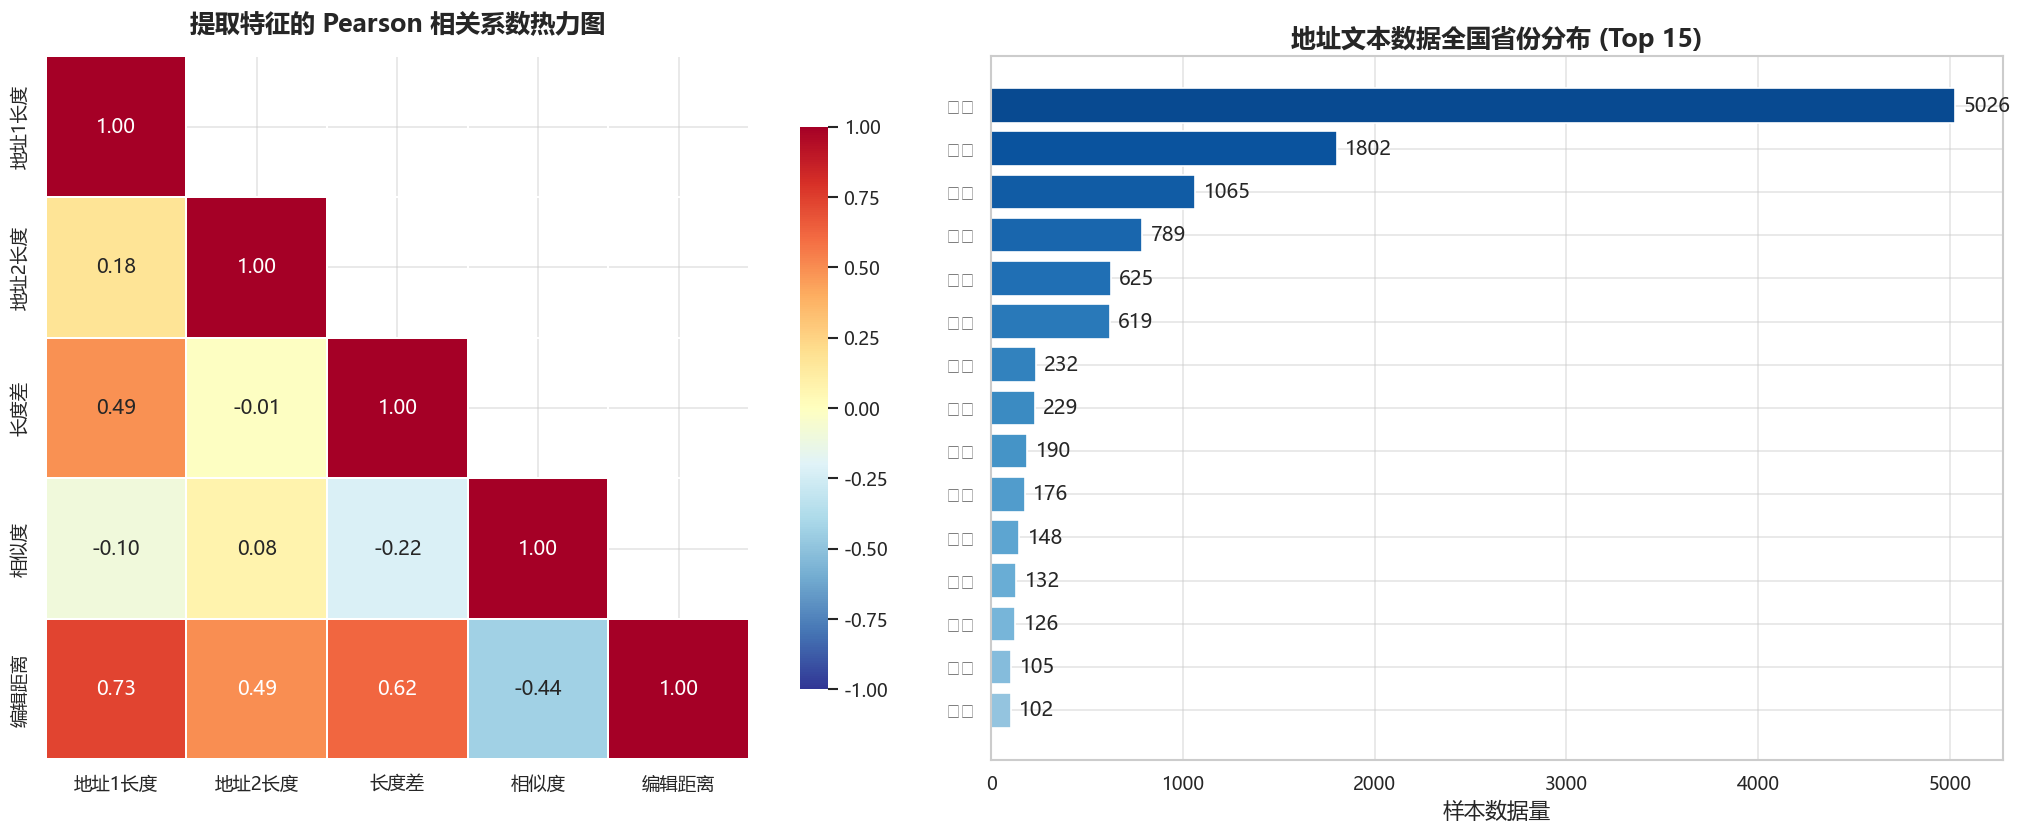

In [16]:
fig, (ax_heat, ax_geo) = plt.subplots(1, 2, figsize=(18, 7))

# ----------------- 1. 热力图 -----------------
# 挑选出想看相关性的列
numeric_cols = ["len1", "len2", "len_diff", "jaccard", "edit_dist"]
col_names_cn = ["地址1长度", "地址2长度", "长度差", "相似度", "编辑距离"]

corr = df[numeric_cols].corr() # 核心代码：计算相关性矩阵
corr.index = col_names_cn
corr.columns = col_names_cn

# 遮罩：把右上角多余的镜像部分藏起来，只留左下角三角形，看起来更高端
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

# annot=True 会把数字写在格子里；cmap="RdYlBu_r" 是蓝-黄-红的经典冷暖色带
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlBu_r", 
            center=0, vmin=-1, vmax=1, square=True, 
            linewidths=1, ax=ax_heat, cbar_kws={"shrink": 0.8})
ax_heat.set_title("提取特征的 Pearson 相关系数热力图", fontsize=15, fontweight="bold", pad=15)

# ----------------- 2. 地理分布条形图 -----------------
prov_counts = df[df["province"] != "未知"]["province"].value_counts()
top_n = min(15, len(prov_counts))
prov_top = prov_counts.head(top_n)

# 绘制水平条形图 (barh)，由于是水平的所以 index 当 Y 轴
colors = plt.cm.Blues(np.linspace(0.4, 0.9, top_n))[::-1]
bars = ax_geo.barh(range(top_n), prov_top.values, color=colors, edgecolor="white")

ax_geo.set_yticks(range(top_n))
ax_geo.set_yticklabels(prov_top.index, fontsize=12, fontfamily=plt.rcParams["font.sans-serif"][0])
ax_geo.invert_yaxis() # 从上到下显示排名第一的省份
ax_geo.set_xlabel("样本数据量", fontsize=13)
ax_geo.set_title(f"地址文本数据全国省份分布 (Top {top_n})", fontsize=15, fontweight="bold")

# 在柱子末端写上具体的数字
for bar in bars:
    width = bar.get_width()
    ax_geo.annotate(f"{int(width)}", xy=(width, bar.get_y() + bar.get_height() / 2),
                    xytext=(5, 0), textcoords="offset points", ha="left", va="center")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Heatmap_and_Geo_Bar.png")
plt.show()


## 模块五：文本实体与网络图 (WordCloud & Network Graph)

这个模块是最耗性能、但分析深度最高的模块。

**1. 词云图 (WordCloud)**：
将“完全匹配”的句子全部拼接在一起，用 jieba 库把长句子切成词。
过滤掉停用词（如“省”、“市”、“区”、“的”这些无意义的高频字）后，根据每个词出现的次数，字体越大代表频率越高。

**2. 实体关联网络图 (Co-occurrence Network)**：
这是满足你队友“Network / 节点图”要求的大招。
- 原理：如果“阿里巴巴”和“余杭区”经常在同一条地址记录里一起出现，那说明它们之间有很强的关联（共现）。
- 实现：我们用 `jieba.posseg` 对每句话进行词性标注。只抽取出 `ns`（地名）和 `n`（名词）实体。如果在同一句话中两个词一起出现了，就在图论模型中连一条边。边越多，线条越粗。
- 最后，使用 `networkx` 库计算整个图谱的布局（弹簧斥力布局 Spring Layout），并画出像超级大脑一样复杂的关联图谱。


正在抽取文本实体构建共现网络 (Network)... 这可能需要十几秒钟...


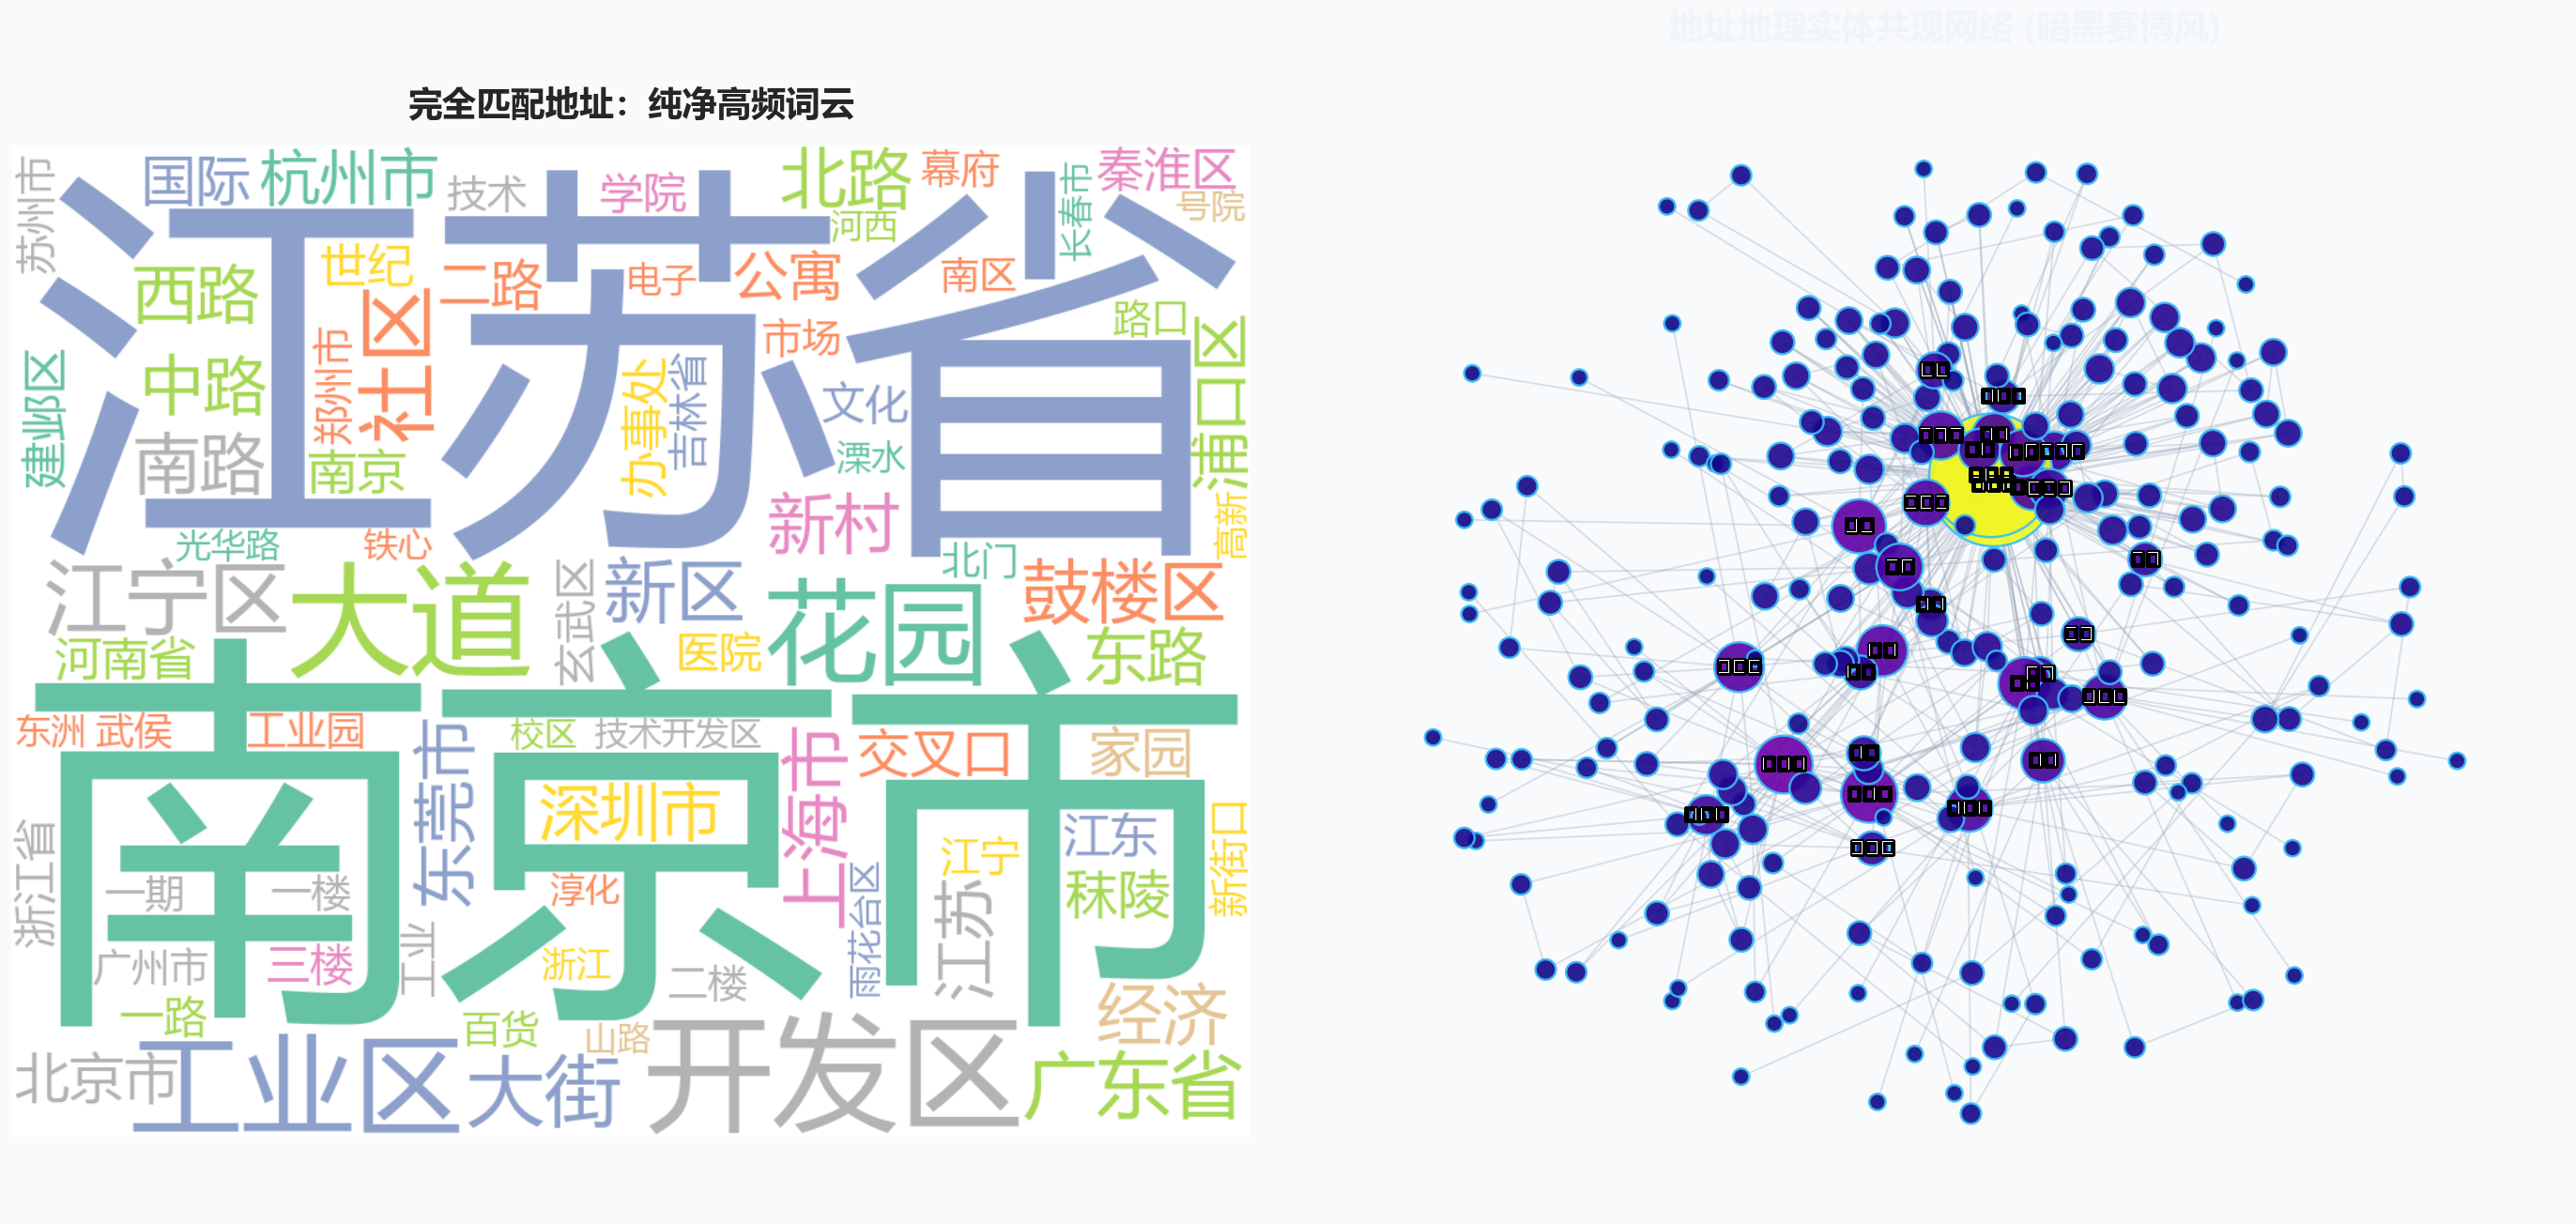

In [17]:
# 为了加快演示速度，我们随机抽取 5000 条数据用于画图。
sample_df = df.sample(n=min(5000, len(df)), random_state=42)

# 定义停用词集合（过滤掉无实际业务价值的纯修饰词、数字、单字）
STOP_WORDS = {"省", "市", "区", "县", "镇", "乡", "街道", "路", "号", 
              "室", "层", "门", "旁", "的", "内", "外", "中心", "广场", "大厦", "小区",
              "公司", "有限公司", "单元", "号楼", "股份", "分公司", "时代", "科技", "发展"}

# ----------------- 准备词云数据 -----------------
exact_match_texts = " ".join(sample_df[sample_df["label"] == "exact_match"]["sentence1"])
words = list(jieba.cut(exact_match_texts))
# 过滤：长度必须大于1，且全是中文，且不在停用词表里
import re
filtered_words = [w for w in words if len(w) > 1 and w not in STOP_WORDS and re.match(r'^[一-龥]+$', w)]
word_freq = Counter(filtered_words)

# ----------------- 准备网络图数据 -----------------
print("正在抽取文本实体构建共现网络 (Network)... 这可能需要十几秒钟...")
edge_weights = Counter()

# 用 2000 条画网络，保证数据量充足但不会爆炸
for text in sample_df["sentence1"].tolist()[:2000]: 
    words_pos = list(pseg.cut(text))
    # 只保留长度>=2 的地名(ns) 或 机构名(nt)，过滤普通名词让图谱更聚焦于“地理实体”
    entities = [pair.word for pair in words_pos 
                if pair.flag in ['ns', 'nt'] and len(pair.word) >= 2 and pair.word not in STOP_WORDS]
    
    # 实体去重，避免一句话里同一个词自己和自己连线
    entities = list(set(entities))
    for i in range(len(entities)):
        for j in range(i + 1, len(entities)):
            pair = tuple(sorted((entities[i], entities[j])))
            edge_weights[pair] += 1

# 构建无向图
G = nx.Graph()
# 提高阈值：只保留共同出现次数 >= 2 的核心强关联边，砍掉大量弱关联噪音
for (node1, node2), weight in edge_weights.items():
    if weight >= 2:
        G.add_edge(node1, node2, weight=weight)

# 只提取包含最大连接子图（Core subgraph）的部分
core_components = sorted(nx.connected_components(G), key=len, reverse=True)
G_core = G.subgraph(core_components[0]) if core_components else G

# ================= 炫酷绘图开始 =================
fig = plt.figure(figsize=(24, 12))

# --- 画词云 (左侧) ---
ax_wc = plt.subplot(121)
wc = WordCloud(font_path=FONT_PATH, width=1000, height=800, background_color="white", 
               colormap="Set2", max_words=80)
wc.generate_from_frequencies(word_freq)
ax_wc.imshow(wc, interpolation="bilinear")
ax_wc.axis("off")
ax_wc.set_title("完全匹配地址：纯净高频词云", fontsize=22, fontweight="bold", pad=20)

# --- 画网络图 (右侧，致敬你作业4的暗黑赛博朋克风格) ---
ax_net = plt.subplot(122)
ax_net.set_facecolor("#0F172A") # 深邃暗色背景

# Spring layout 增加 k 值，让节点散得更开
pos = nx.spring_layout(G_core, k=0.5, iterations=50, seed=42)

# 计算度数用于节点大小和颜色映射
degrees = dict(G_core.degree())
node_sizes = [v * 60 + 50 for v in degrees.values()]
node_colors = list(degrees.values())

# 1. 画边（半透明，细线）
nx.draw_networkx_edges(G_core, pos, ax=ax_net, alpha=0.3, edge_color="#94A3B8", width=1.2)

# 2. 画节点（用 plasma 渐变色，带发光边缘效果）
nodes = nx.draw_networkx_nodes(G_core, pos, ax=ax_net, node_size=node_sizes, 
                               node_color=node_colors, cmap=plt.cm.plasma, 
                               alpha=0.9, linewidths=1.5, edgecolors="#38BDF8")

# 3. 画标签（只给度数排名前 30 的核心枢纽节点打标签，避免拥挤）
top_nodes = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:30]
high_degree_nodes = {node: node for node, deg in top_nodes}

# 为文字添加发光轮廓以便在暗色背景上看清
import matplotlib.patheffects as path_effects
labels = nx.draw_networkx_labels(G_core, pos, labels=high_degree_nodes, ax=ax_net, 
                        font_size=13, font_weight="bold", font_family=plt.rcParams["font.sans-serif"][0],
                        font_color="white")
for _, t in labels.items():
    t.set_path_effects([path_effects.Stroke(linewidth=3, foreground='black'), path_effects.Normal()])

ax_net.set_title("地址地理实体共现网络 (暗黑赛博风)", fontsize=22, fontweight="bold", color="#F1F5F9", pad=20)
ax_net.axis("off")

# 整体背景调整
fig.patch.set_facecolor("#F8FAFC") 
plt.tight_layout(pad=4.0)
plt.savefig(OUTPUT_DIR / "WordCloud_and_Network.png", dpi=300, facecolor=fig.get_facecolor())
plt.show()


In [18]:
# ==============================================================================
# 模块六：可拖拽的动态交互网络图 (使用 Pyecharts)
# ==============================================================================
# 刚才用 matplotlib 画的暗黑网络图虽然精美，但它是静态图片。
# 既然你要求“动态拖拽”的效果，在这里我们使用国内非常流行的数据可视化库 Pyecharts，
# 构建一个浏览器原生支持的 力导向图 (Force-directed Graph)。
# 鼠标可以悬浮查看数据，可以滚轮缩放，还可以自由拖拽节点！

from pyecharts import options as opts
from pyecharts.charts import Graph
import math

# 1. 准备 Pyecharts 所需的节点格式
py_nodes = []
for node in G_core.nodes():
    deg = G_core.degree(node)
    # 用度数算一个合适的圆圈大小
    symbol_size = max(10, math.sqrt(deg) * 12) 
    py_nodes.append({
        "name": node,
        "symbolSize": symbol_size,
        "value": deg # 悬浮时显示的值
    })

# 2. 准备 Pyecharts 所需的连线格式
py_edges = []
for source, target, data in G_core.edges(data=True):
    py_edges.append({
        "source": source,
        "target": target,
        "value": data['weight']
    })

# 3. 组装交互图表
interactive_graph = (
    Graph(init_opts=opts.InitOpts(width="100%_1", height="800px", theme="dark".replace("_1", ""))) # 暗黑主题
    .add(
        series_name="实体",
        nodes=py_nodes,
        links=py_edges,
        layout="force",    # 核心：设置为力导向布局，实现物理碰撞和拖拽效果
        repulsion=600,     # 节点之间的斥力，越大节点散得越开
        gravity=0.1,       # 往中心靠拢的引力
        edge_symbol=[None, None], 
        label_opts=opts.LabelOpts(
            is_show=True, 
            position="right",
            color="white"  # 标签颜色
        ),
        linestyle_opts=opts.LineStyleOpts(width=1, opacity=0.2, curve=0.2), # 连线带一点优雅的弧度
    )
    .set_global_opts(
        title_opts=opts.TitleOpts(title="地址地理实体交互网络图 (请尝试拖拽节点！)", 
                                  subtitle="滚轮可缩放，鼠标悬浮可查看度数"),
        legend_opts=opts.LegendOpts(is_show=False),
        tooltip_opts=opts.TooltipOpts(formatter="{b}: 核心连接度 {c}") # 鼠标悬浮提示框
    )
)

# 4. 直接在 Notebook 中输出动态可交互的网页控件
# （如果运行后空白，说明 Jupyter 需要信任该库或重新加载页面）
interactive_graph.render_notebook()
